## Question 1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
def intensity_transform(im, breakpoints):
    """
    Applying a piecewise-linear intensity transformation defined by breakpoints.
    """
    bp = np.array(breakpoints, dtype=np.float64)
    lut = np.zeros(256, dtype=np.float64)
    levels = np.arange(256)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        if i == len(bp) - 2:
            mask = (levels >= x0) & (levels <= x1)
        else:
            mask = (levels >= x0) & (levels < x1)
        if x1 == x0:
            lut[mask] = y1
        else:
            lut[mask] = y0 + (y1 - y0) * (levels[mask] - x0) / (x1 - x0)

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut), lut


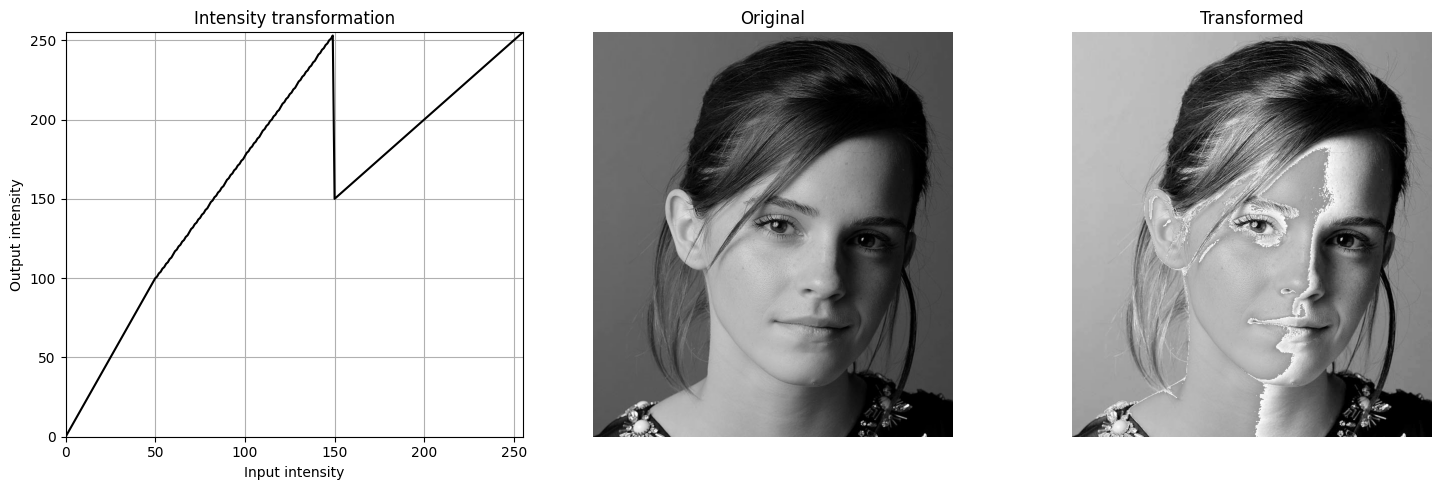

In [3]:
img = cv2.imread('images/emma.jpg', cv2.IMREAD_GRAYSCALE)

breakpoints = [[0, 0], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 2

### (a) Accentuating white matter

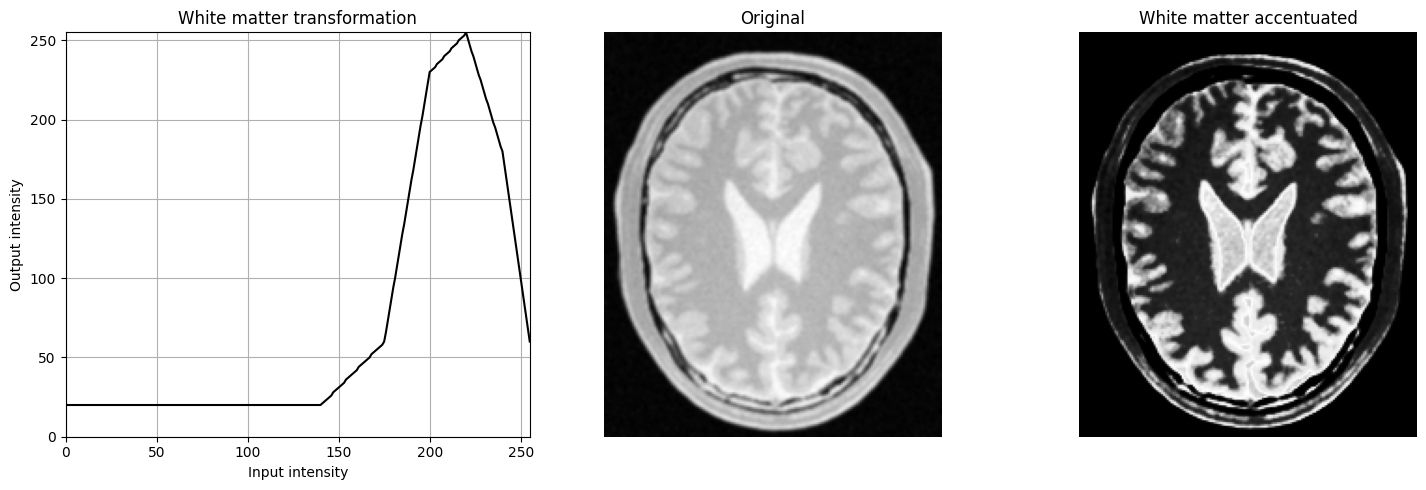

In [4]:
img2 = cv2.imread('images/brain_proton_density.jpeg', cv2.IMREAD_GRAYSCALE)
# A light blur first suppresses JPEG blockiness so the stretch below doesn't
# turn compression artifacts into visible noise.
img2 = cv2.GaussianBlur(img2, (3, 3), 0)

# White matter sits roughly in the 200-220 intensity band in this image.
# So we need a ramp that band up towards 255 while suppressing everything else.
white_bp = [[0, 20], [140, 20], [175, 60], [200, 230], [220, 255], [240, 180], [255, 60]]

# Reusing the same intensity_transform function from Q1
white_out, white_lut = intensity_transform(img2, white_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), white_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray')
axes[2].set_title('White matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Accentuating gray matter

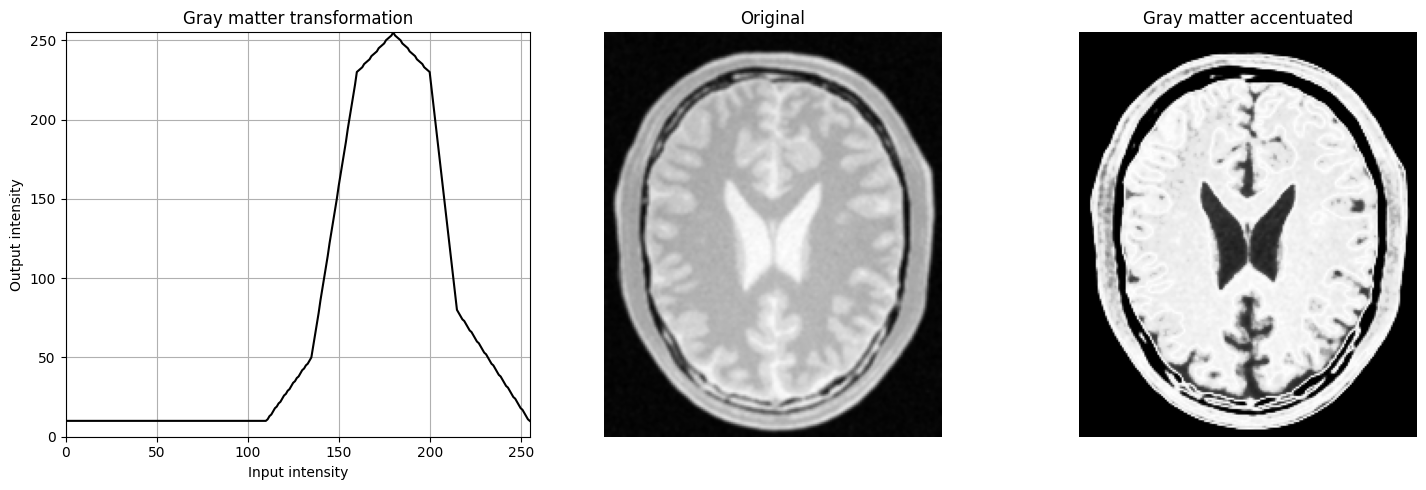

In [5]:
# Gray matter sits in a lower band (160-180), so we need to increase that
# while suppressing background, white matter, and the skull/scalp.
gray_bp = [[0, 10], [110, 10], [135, 50], [160, 230], [180, 255], [200, 230], [215, 80], [255, 10]]

gray_out, gray_lut = intensity_transform(img2, gray_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), gray_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 3

### (a) Gamma correction on the L plane in L*a*b* space

gamma = 0.5

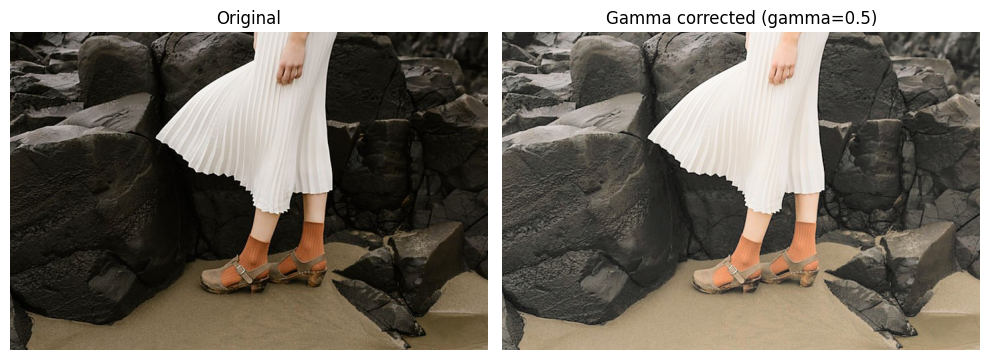

In [6]:
img3 = cv2.imread('images/gamma_correction.jpeg')
lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Most of the image (the rocks) is dark, so gamma < 1 lifts the shadows
gamma = 0.5
L_corrected = (255.0 * (L / 255.0) ** gamma).clip(0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_corrected, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (gamma={gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### (b) Histograms before and after correction

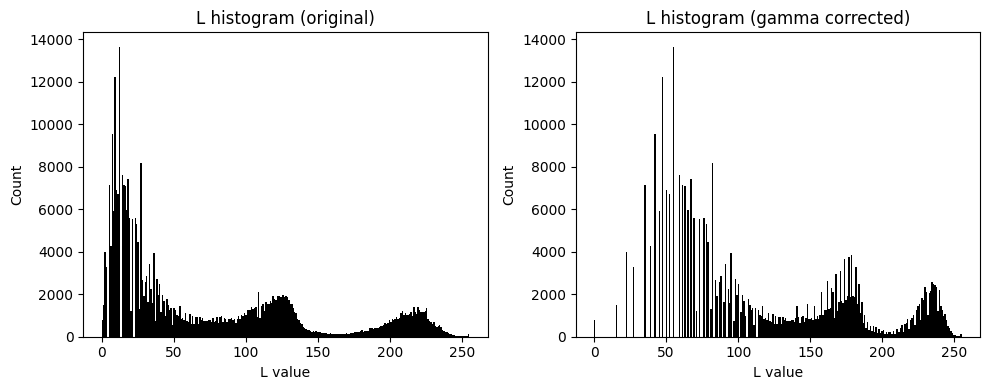

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(L.flatten(), bins=256, range=(0, 255), color='k')
axes[0].set_title('L histogram (original)')
axes[0].set_xlabel('L value')
axes[0].set_ylabel('Count')

axes[1].hist(L_corrected.flatten(), bins=256, range=(0, 255), color='k')
axes[1].set_title('L histogram (gamma corrected)')
axes[1].set_xlabel('L value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Question 4

### (a) Split into hue, saturation, and value planes

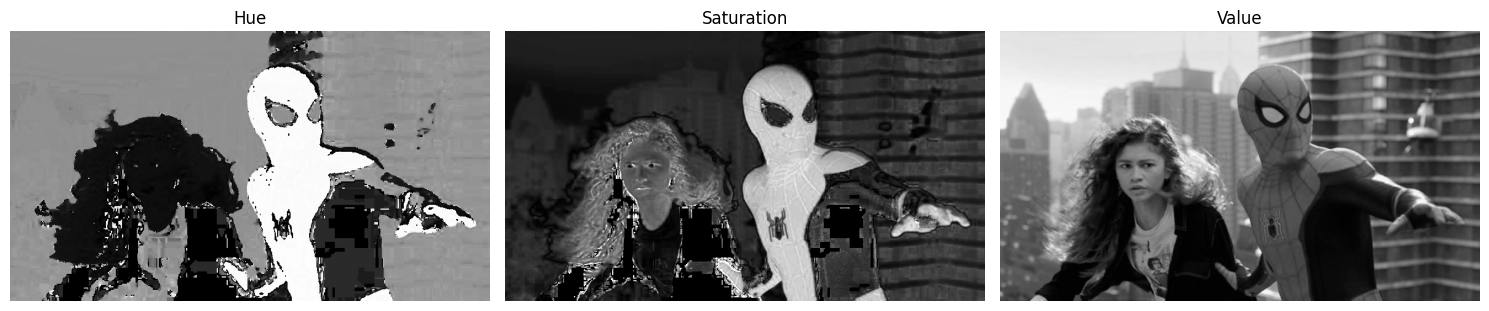

In [8]:
img4 = cv2.imread('images/vibrance.jpeg')
hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(H, cmap='gray')
axes[0].set_title('Hue')
axes[0].axis('off')

axes[1].imshow(S, cmap='gray')
axes[1].set_title('Saturation')
axes[1].axis('off')

axes[2].imshow(V, cmap='gray')
axes[2].set_title('Value')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Apply the vibrance transformation to the saturation plane

In [9]:
sigma = 70
a = 0.8  # chosen by trying a few values and picking the most visually pleasing

x = np.arange(256).astype(np.float64)
vibrance_curve = np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255)
vibrance_lut = vibrance_curve.astype(np.uint8)

S_boosted = cv2.LUT(S, vibrance_lut)


### (c) Choosing the value for 'a'
Chose a = 0.8 (It was the most visually pleasing value)

### (d) Recombine the planes

In [10]:
hsv_boosted = cv2.merge([H, S_boosted, V])
img4_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)


### (e) Original, vibrance-enhanced image, and the transformation

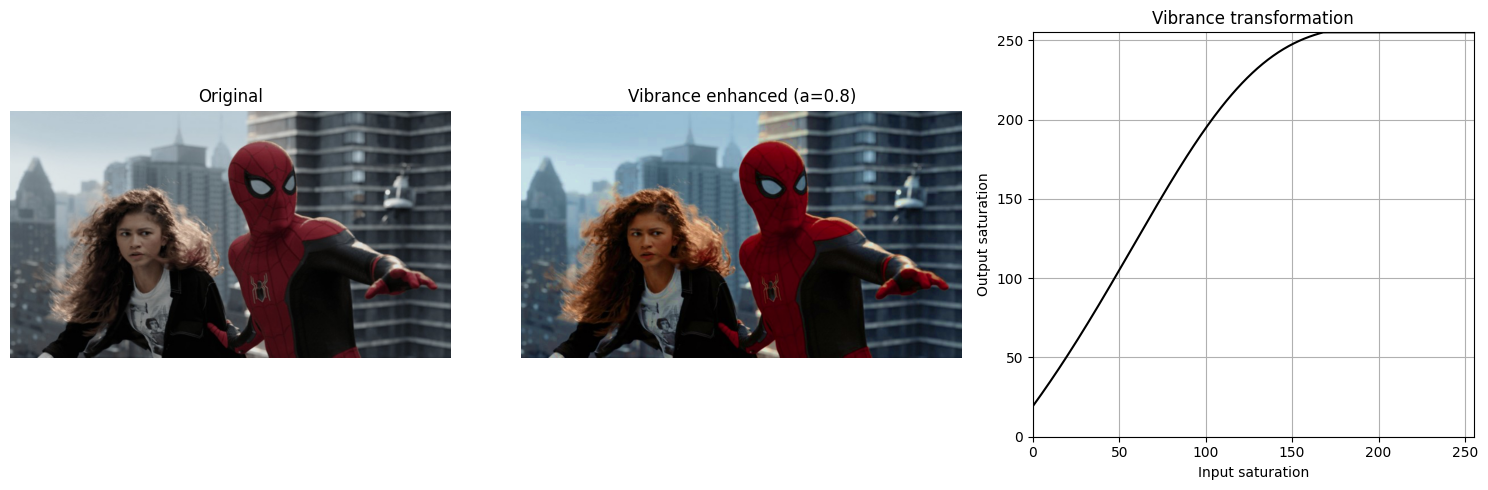

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img4_boosted, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a={a})')
axes[1].axis('off')

axes[2].plot(x, vibrance_curve, color='k')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Vibrance transformation')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## Question 5

In [12]:
def histogram_equalization(im):
    """Equalize the histogram of a grayscale image using its cumulative
    distribution function, mapped to the full 0-255 range."""
    hist = np.bincount(im.flatten(), minlength=256)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    lut = (cdf - cdf_min) / (cdf[-1] - cdf_min) * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]


[ WARN:0@3.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


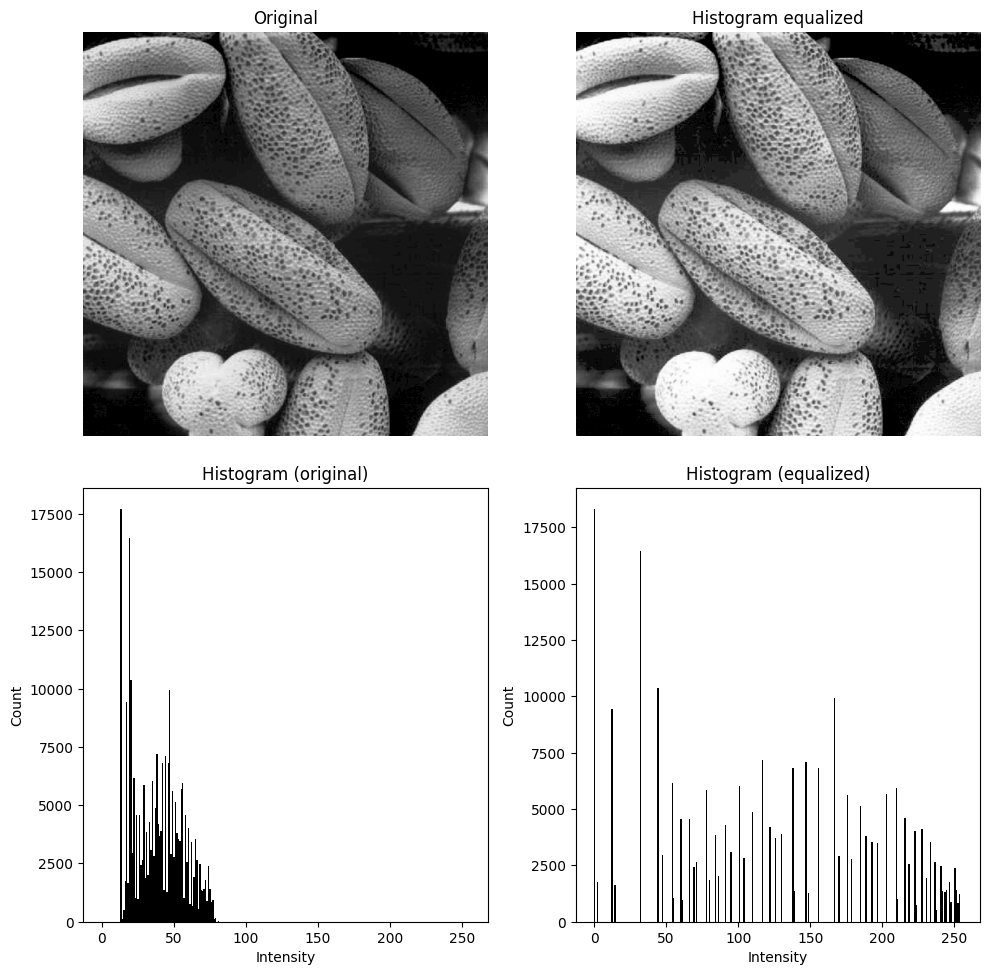

In [13]:
img5 = cv2.imread('images/shells.tif', cv2.IMREAD_GRAYSCALE)
img5_eq = histogram_equalization(img5)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img5, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img5_eq, cmap='gray')
axes[0, 1].set_title('Histogram equalized')
axes[0, 1].axis('off')

axes[1, 0].hist(img5.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 0].set_title('Histogram (original)')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(img5_eq.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 1].set_title('Histogram (equalized)')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Question 6

### (a) Split into hue, saturation, and value planes

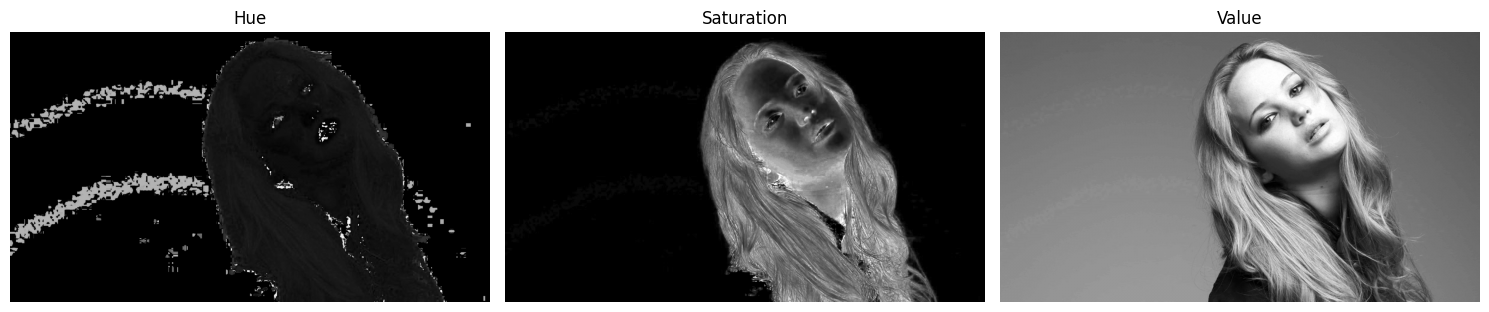

In [14]:
img6 = cv2.imread('images/foreground_segmentation.jpeg')
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(H6, cmap='gray')
axes[0].set_title('Hue')
axes[0].axis('off')

axes[1].imshow(S6, cmap='gray')
axes[1].set_title('Saturation')
axes[1].axis('off')

axes[2].imshow(V6, cmap='gray')
axes[2].set_title('Value')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Threshold to extract the foreground mask

Neither the saturation plane nor the value plane alone cleanly separates the person from the background (the background has a brightness gradient that overlaps the skin/hair tones), so both are thresholded and combined.

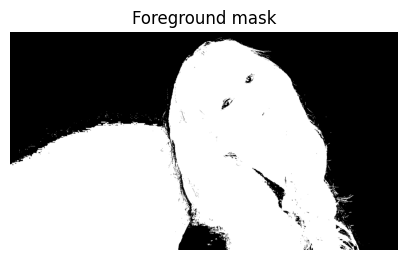

In [ ]:
# Otsu's threshold on saturation catches the hair and clothing, and Otsu's
# threshold on value catches the brighter side of the face, combine both
mask_s = cv2.threshold(S6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
mask_v = cv2.threshold(V6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
mask = cv2.bitwise_or(mask_s, mask_v)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.title('Foreground mask')
plt.axis('off')
plt.show()


### (c) Extract the foreground and compute its histogram

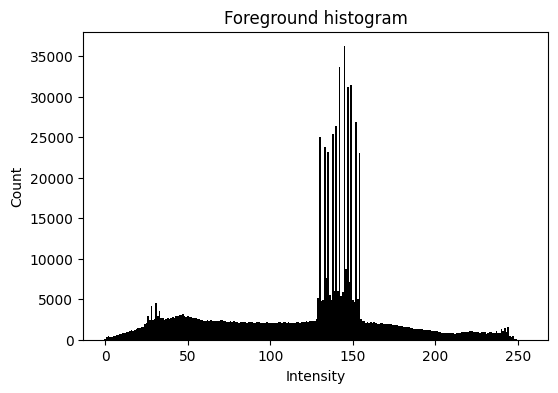

In [ ]:
gray6 = cv2.cvtColor(img6, cv2.COLOR_BGR2GRAY)
foreground = cv2.bitwise_and(gray6, gray6, mask=mask)

# Histogram computed only over the masked in (foreground) pixels
hist = cv2.calcHist([gray6], [0], mask, [256], [0, 256]).flatten()

plt.figure(figsize=(6, 4))
plt.bar(np.arange(256), hist, color='k', width=1)
plt.title('Foreground histogram')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()


### (d) Cumulative sum of the foreground histogram

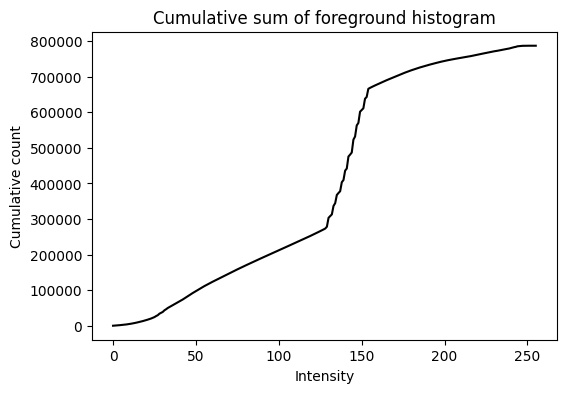

In [17]:
cdf = np.cumsum(hist)

plt.figure(figsize=(6, 4))
plt.plot(cdf, color='k')
plt.title('Cumulative sum of foreground histogram')
plt.xlabel('Intensity')
plt.ylabel('Cumulative count')
plt.show()


### (e) Histogram-equalize the foreground

In [ ]:
cdf_min = cdf[cdf > 0].min()
lut = np.clip((cdf - cdf_min) / (cdf[-1] - cdf_min) * 255, 0, 255).astype(np.uint8)

# Reusing the same equalization formula as Q5, but the LUT is built only from the foreground's own histogram
foreground_eq_full = lut[gray6]
foreground_eq = cv2.bitwise_and(foreground_eq_full, foreground_eq_full, mask=mask)


### (f) Extract the background and add it to the equalized foreground

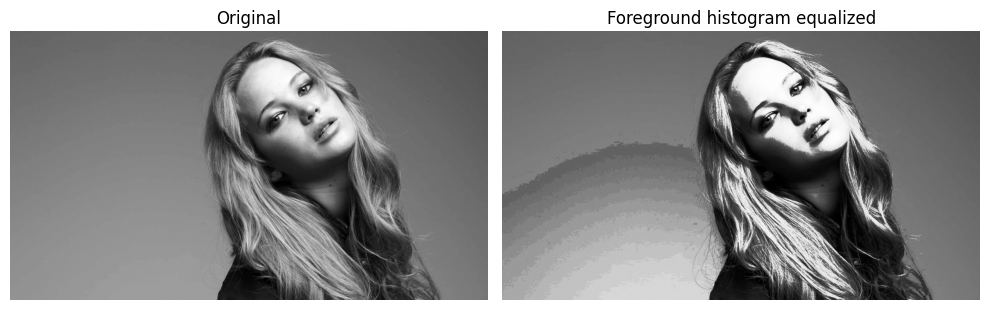

In [19]:
background = cv2.bitwise_and(gray6, gray6, mask=cv2.bitwise_not(mask))
result6 = cv2.add(foreground_eq, background)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray6, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(result6, cmap='gray')
axes[1].set_title('Foreground histogram equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()
